In [1]:
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, confusion_matrix)
from sklearn.base import clone
import pandas as pd
import numpy as np
import time

def print_metrics(y_true, y_pred, label):
    print(label)
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score:  {f1_score(y_true, y_pred):.4f}")

def print_confusion(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(label)
    print(f"  TP (corruptas detectadas):     {tp}")
    print(f"  FN (corruptas NO detectadas):  {fn}")
    print(f"  FP (limpias marcadas corrupta):{fp}")
    print(f"  TN (limpias correctas):        {tn}")

def random_forest(save_model=True):

    ####################
    # TRAINING
    ####################

    data_train = pd.concat([
        pd.read_csv("csv/train/clean.csv", header=0, dtype={"video": str}),
        pd.read_csv("csv/train/corrupted.csv", header=0, dtype={"video": str})
    ], ignore_index=True)
    X_train = data_train.drop(columns=["video", "label"])
    y_train = data_train["label"].values
    groups  = data_train["video"]

    rf = RandomForestClassifier(n_estimators=100, n_jobs=-1)
    gkf = GroupKFold(n_splits=10)

    fold_acc, fold_prec, fold_rec, fold_f1, fold_fit_time = [], [], [], [], []

    print(f"Iniciando cross-validation (10 folds, {len(X_train)} muestras, {X_train.shape[1]} features)...")
    cv_start = time.time()

    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train, groups), start=1):
        fold_start = time.time()
        rf_fold = clone(rf)
        rf_fold.fit(X_train.iloc[tr_idx], y_train[tr_idx])
        y_pred = rf_fold.predict(X_train.iloc[va_idx])
        elapsed = time.time() - fold_start
        fold_fit_time.append(elapsed)
        fold_acc.append(accuracy_score(y_train[va_idx], y_pred))
        fold_prec.append(precision_score(y_train[va_idx], y_pred))
        fold_rec.append(recall_score(y_train[va_idx], y_pred))
        fold_f1.append(f1_score(y_train[va_idx], y_pred))
        remaining = np.mean(fold_fit_time) * (10 - fold)
        print(f"  Fold {fold:2d}/10 | recall={fold_rec[-1]:.4f} | f1={fold_f1[-1]:.4f} | "
              f"{elapsed:.0f}s | restante estimado: {remaining:.0f}s")

    print(f"CV completado en {time.time() - cv_start:.0f}s\n")

    print("Entrenando modelo final")
    t0 = time.time()
    rf.fit(X_train, y_train)
    train_time = time.time() - t0
    print(f"Entrenamiento final: {train_time:.1f}s\n")

    if save_model:
        joblib.dump(rf, "models/corruption_detector.pkl")
        print("Modelo guardado en models/corruption_detector.pkl\n")

    ####################
    # TEST
    ####################

    data_test = pd.concat([
        pd.read_csv("csv/test/clean.csv", header=0, dtype={"video": str}),
        pd.read_csv("csv/test/corrupted.csv", header=0, dtype={"video": str})
    ], ignore_index=True)
    X_test = data_test.drop(columns=["video", "label"])
    y_test = data_test["label"].values
    n_images_test = len(y_test)

    t0 = time.time()
    y_test_pred = rf.predict(X_test)
    test_time = (time.time() - t0) * 1000 / n_images_test

    y_probs_test = rf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs_test)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4.5))
    plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC curve")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

    print("Cross-Validation (GroupKFold por vídeo)")
    print(f"  Accuracy:  {np.mean(fold_acc):.4f} +/- {np.std(fold_acc):.4f}")
    print(f"  Precision: {np.mean(fold_prec):.4f} +/- {np.std(fold_prec):.4f}")
    print(f"  Recall:    {np.mean(fold_rec):.4f} +/- {np.std(fold_rec):.4f}")
    print(f"  F1 Score:  {np.mean(fold_f1):.4f} +/- {np.std(fold_f1):.4f}")

    print("\nTest")
    print_metrics(y_test, y_test_pred, "")
    print(f"  AUC:       {roc_auc:.4f}")

    print()
    print_confusion(y_test, y_test_pred, "Matriz de confusión (Test)")

    print("\nTimes")
    print(f"Train time: {train_time:.4f} seconds")
    print(f"Test time:  {test_time:.4f} ms/image")

Iniciando cross-validation (10 folds, 113214 muestras, 540 features)...
  Fold  1/10 | recall=0.8156 | f1=0.8332 | 36s | restante estimado: 320s
  Fold  2/10 | recall=0.8449 | f1=0.8353 | 37s | restante estimado: 292s
  Fold  3/10 | recall=0.8476 | f1=0.8474 | 37s | restante estimado: 257s
  Fold  4/10 | recall=0.7655 | f1=0.7826 | 35s | restante estimado: 217s
  Fold  5/10 | recall=0.8435 | f1=0.8378 | 33s | restante estimado: 178s
  Fold  6/10 | recall=0.8127 | f1=0.7340 | 38s | restante estimado: 144s
  Fold  7/10 | recall=0.8572 | f1=0.8164 | 37s | restante estimado: 109s
  Fold  8/10 | recall=0.8560 | f1=0.8327 | 34s | restante estimado: 72s
  Fold  9/10 | recall=0.7784 | f1=0.8022 | 32s | restante estimado: 36s
  Fold 10/10 | recall=0.8742 | f1=0.7445 | 33s | restante estimado: 0s
CV completado en 353s

Entrenando modelo final...
Entrenamiento final: 36.5s

Modelo guardado en models/corruption_detector.pkl



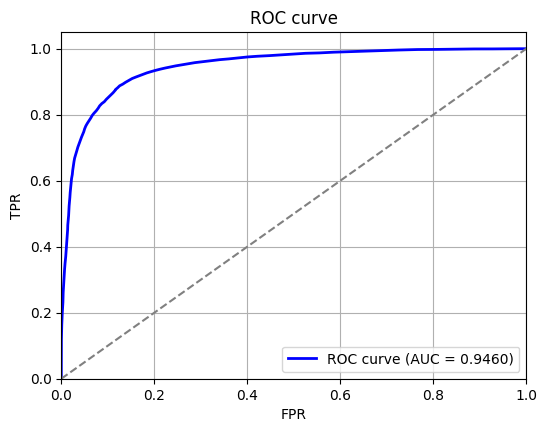

Cross-Validation (GroupKFold por vídeo)
  Accuracy:  0.8092 +/- 0.0249
  Precision: 0.7892 +/- 0.0684
  Recall:    0.8295 +/- 0.0338
  F1 Score:  0.8066 +/- 0.0383

Test

  Accuracy:  0.8733
  Precision: 0.9051
  Recall:    0.8269
  F1 Score:  0.8643
  AUC:       0.9460

Matriz de confusión (Test)
  TP (corruptas detectadas):     11161
  FN (corruptas NO detectadas):  2336
  FP (limpias marcadas corrupta):1170
  TN (limpias correctas):        13009

Times
Train time: 36.4817 seconds
Test time:  0.0075 ms/image


In [2]:
random_forest()

Mal clasificadas: 3506 / 27676
label  predicted
1      0            2336
0      1            1170
Name: count, dtype: int64


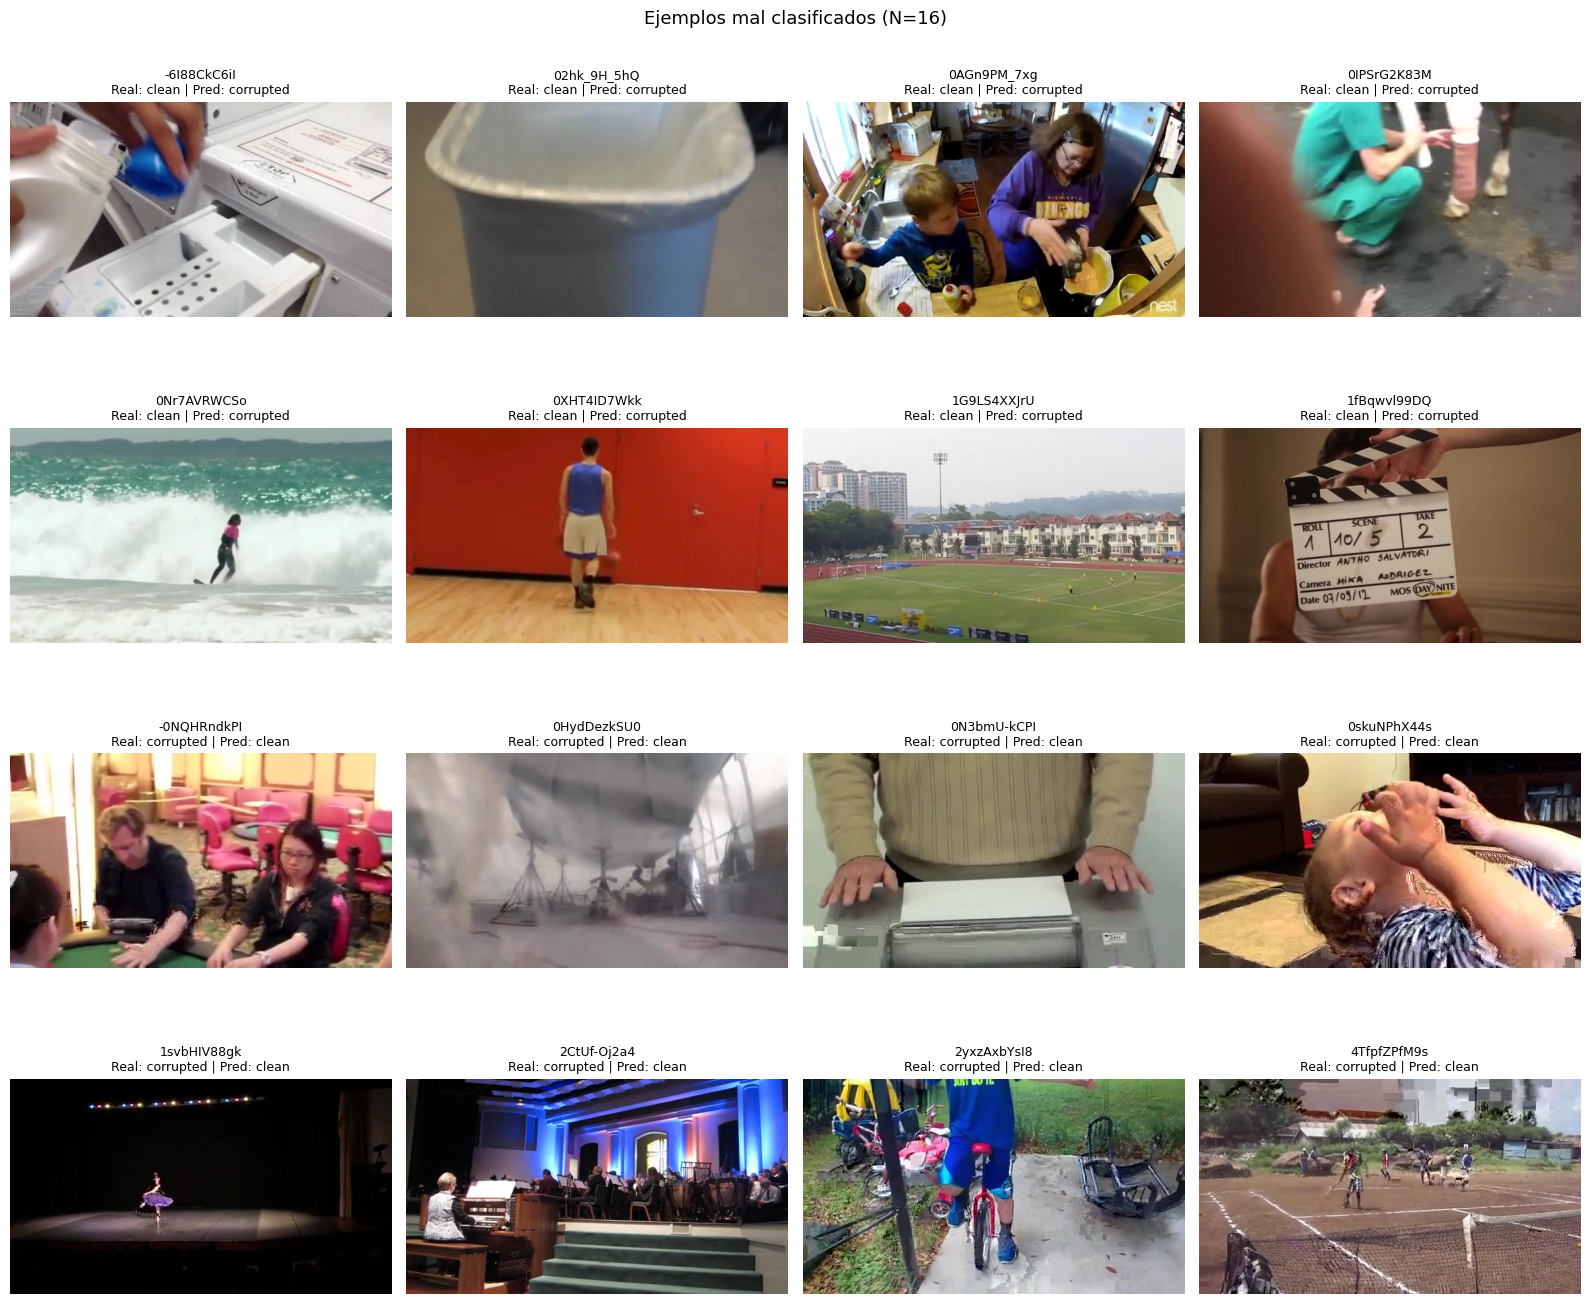

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random, math
from pathlib import Path
import joblib
import pandas as pd
import numpy as np

N_EXAMPLES = 16  # <-- cambia este valor
FRAMES_DIR = Path("../frames/test")

rf_loaded = joblib.load("models/corruption_detector.pkl")

data_test = pd.concat([
    pd.read_csv("csv/test/clean.csv",     header=0, dtype={"video": str}),
    pd.read_csv("csv/test/corrupted.csv", header=0, dtype={"video": str}),
], ignore_index=True)

X_test = data_test.drop(columns=["video", "label"])
y_test = data_test["label"].values
y_pred = rf_loaded.predict(X_test)

mask = y_pred != y_test
misclassified = data_test[mask].copy()
misclassified["predicted"] = y_pred[mask]

print(f"Mal clasificadas: {mask.sum()} / {len(y_test)}")
print(misclassified[["label", "predicted"]].value_counts())

def get_frame_files_for_video(video_stem):
    return list(FRAMES_DIR.rglob(f"{video_stem}_*.jpg"))

half   = N_EXAMPLES // 2
fp     = misclassified[misclassified["label"] == 0].drop_duplicates(subset="video").head(half)
fn     = misclassified[misclassified["label"] == 1].drop_duplicates(subset="video").head(N_EXAMPLES - half)
sample = pd.concat([fp, fn], ignore_index=True)

n_cols = min(N_EXAMPLES, 4)
n_rows = math.ceil(N_EXAMPLES / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.flatten() if N_EXAMPLES > 1 else [axes]

for ax_i, (_, row) in enumerate(sample.iterrows()):
    video_stem = row["video"]
    true_lbl   = int(row["label"])
    pred_lbl   = int(row["predicted"])
    files      = get_frame_files_for_video(video_stem)

    if files:
        img = mpimg.imread(str(random.choice(files)))
        axes[ax_i].imshow(img, cmap="gray")
        axes[ax_i].set_title(
            f"{video_stem}\nReal: {'corrupted' if true_lbl else 'clean'} | "
            f"Pred: {'corrupted' if pred_lbl else 'clean'}",
            fontsize=9
        )
    else:
        axes[ax_i].set_title(f"{video_stem}\n(frames no encontrados)", fontsize=9)
    axes[ax_i].axis("off")

for ax_i in range(len(sample), n_rows * n_cols):
    axes[ax_i].axis("off")

plt.suptitle(f"Ejemplos mal clasificados (N={N_EXAMPLES})", fontsize=13)
plt.tight_layout()
plt.show()